In [ ]:
import numpy as np
from numpy.typing import NDArray
from qiskit import QuantumCircuit

# Traditional Mitigation

Mitigate the readout error in the end.

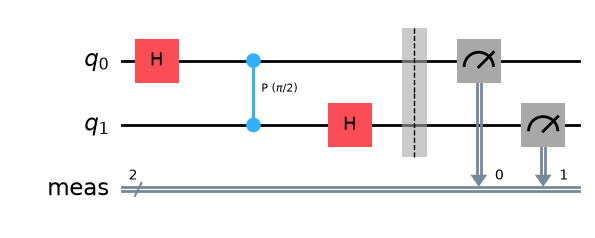

In [2]:
# 2-qubit QFT: unitary
qft_unitary = QuantumCircuit(2)
qft_unitary.h(0)
qft_unitary.cp(np.pi / 2, 0, 1)
qft_unitary.h(1)
qft_unitary.measure_all()

qft_unitary.draw("mpl")

In [3]:
# define the noise model: only readout error on q0
from qiskit_aer.noise import NoiseModel, ReadoutError

eps: float = 0.1

# Column-vector convention: p_noisy = A_q0 @ p_ideal.
# A_q0[measured, ideal] = P(measured | ideal).
A_q0: np.ndarray = np.array([[1 - eps, eps], [eps, 1 - eps]])

noise_model = NoiseModel()
noise_model.add_readout_error(
    # Aer expects probabilities[ideal, measured], hence the transpose.
    ReadoutError(A_q0.T),
    [0],
)

noise_model.to_dict()

{'errors': [{'type': 'roerror',
   'operations': ['measure'],
   'probabilities': [[0.9, 0.1], [0.1, 0.9]],
   'gate_qubits': [(0,)]}]}

In [4]:
# define the sampler
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import Sampler

sampler = Sampler(mode=AerSimulator(noise_model=noise_model))

In [5]:
# sample function
from collections import Counter

from qiskit.primitives import BitArray, DataBin, PrimitiveResult, SamplerPubResult


def sample_counts(
    circuit: QuantumCircuit,
    sampler: Sampler,
    num_shots: int,
    register_name: str = "c",
) -> Counter[int]:
    """Run a sampler and return bitstring counts.

    Args:
        circuit: Circuit to execute.
        sampler: Sampler to use.
        num_shots: Number of shots.
        register_name: Name of the classical register in the result payload.

    Returns:
        dict[str, int]: Bitstring counts.
    """

    result: PrimitiveResult[SamplerPubResult] = sampler.run(
        [circuit], shots=num_shots
    ).result()
    data_bin: DataBin = result[0].data
    bit_array: BitArray = data_bin[register_name]
    counts: dict[int, int] = bit_array.get_int_counts()
    return Counter(counts)

In [6]:
# sample
circ_prepare = QuantumCircuit(2)
circ_prepare.h(0)
circ_prepare.h(1)

circ_total = circ_prepare.compose(qft_unitary, inplace=False)

num_shots = 10**6
cnt = sample_counts(circ_total, sampler, num_shots, register_name="meas")

dist_measure = {k: v / num_shots for k, v in cnt.items()}
dist_measure

{0: 0.899552, 1: 0.100448}

In [7]:
# mitigate the readout error
dist_meas = np.array([dist_measure.get(k, 0) for k in range(2**2)])

# Integer ordering is |q1 q0>, so q0 is the least-significant subsystem.
A_full: np.ndarray = np.kron(np.eye(2), A_q0)

dist_mitigated = np.linalg.solve(A_full, dist_meas)

dist_mitigated

array([9.9944e-01, 5.6000e-04, 0.0000e+00, 0.0000e+00])

# Dynamic Mitigation (Wrong method)

Using the same mitigation method for the dynamic circuit.

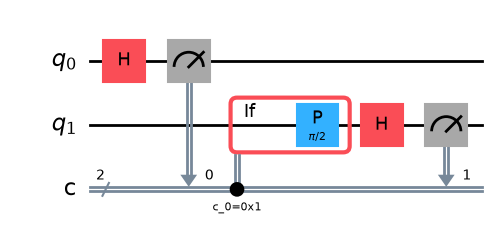

In [8]:
# define dynamic circuit for QFT 2
qft_dynamic = QuantumCircuit(2, 2)
qft_dynamic.h(0)
qft_dynamic.measure(0, 0)

with qft_dynamic.if_test((0, 1)):
    qft_dynamic.p(np.pi / 2, 1)

qft_dynamic.h(1)
qft_dynamic.measure(1, 1)

qft_dynamic.draw("mpl")

In [9]:
# sample
circ_total_dynamic = circ_prepare.compose(qft_dynamic, inplace=False)

num_shots = 10**4
cnt = sample_counts(
    circ_total_dynamic,
    sampler,
    num_shots,
    register_name="c",
)

dist_measure = {k: v / num_shots for k, v in cnt.items()}
dist_measure

{0: 0.8943, 3: 0.0507, 1: 0.055}

In [10]:
# mitigation: using the same method as before
dist_meas = np.array([dist_measure.get(k, 0) for k in range(2**2)])

A_full: np.ndarray = np.kron(np.eye(2), A_q0)

dist_mitigated = np.linalg.solve(A_full, dist_meas)
dist_mitigated

array([ 0.9992125, -0.0499125, -0.0063375,  0.0570375])

# Dynamic Mitigation

定义：
- $G$：无 readout error 时，正向 feed-forward 的完整联合分布，即最终想要的结果。
- $B$：q0 被误读、从而进入错误 feed-forward 分支时的完整联合分布。

正向线路满足：
$$
N=(1-\epsilon)G+\epsilon B
$$

反向线路中：
- 没发生 readout flip 时，进入 bad branch；
- 发生 readout flip 时，反而进入 good branch。

但此时反向线路里的 q0 经典标签与 $G,B$ 相反，所以先将 reverse counts 中的 q0 翻转：
$$
R_{\mathrm{aligned}}(k)=R(k\oplus1)
$$

对齐后才有：
$$
R_{\mathrm{aligned}} = \epsilon G+(1-\epsilon)B
$$

联立求解：
$$
G=
\frac{
(1-\epsilon)N-\epsilon R_{\mathrm{aligned}}
}{
1-2\epsilon
}
$$

这里的 $G$ 已经是完整的 q0+q1 无噪声正向联合分布。

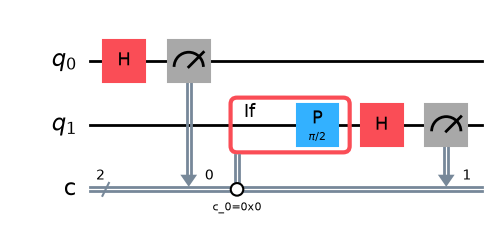

In [11]:
# create reverse dynamic circuit for QFT 2
# 'reverse' means reversing the classical control bit
qft_dynamic_rev = QuantumCircuit(2, 2)
qft_dynamic_rev.h(0)
qft_dynamic_rev.measure(0, 0)

with qft_dynamic_rev.if_test((0, 0)):
    qft_dynamic_rev.p(np.pi / 2, 1)

qft_dynamic_rev.h(1)
qft_dynamic_rev.measure(1, 1)

qft_dynamic_rev.draw("mpl")

In [12]:
# sample both normal and reverse dynamic circuits
circ_total_dynamic = circ_prepare.compose(qft_dynamic, inplace=False)

num_shots = 10**4
cnt = sample_counts(
    circ_total_dynamic,
    sampler,
    num_shots,
    register_name="c",
)

circ_total_dynamic_rev = circ_prepare.compose(qft_dynamic_rev, inplace=False)
cnt_rev = sample_counts(
    circ_total_dynamic_rev,
    sampler,
    num_shots,
    register_name="c",
)

In [13]:
# mitigate
N = 2**2
dist_normal = np.array([cnt.get(k, 0) / num_shots for k in range(N)])
dist_rev = np.array([cnt_rev.get(k, 0) / num_shots for k in range(N)])

indices = np.arange(N)
dist_rev_aligned = dist_rev[indices ^ 1]

dist_mitigated = ((1 - eps) * dist_normal - eps * dist_rev_aligned) / (1 - 2 * eps)
dist_mitigated

array([ 1.002675e+00, -2.100000e-03,  0.000000e+00, -5.750000e-04])

# Non-symmetric Error

Throughout this notebook, probability distributions are column vectors and the assignment matrix is defined by

$$
p_{\mathrm{noisy}} = A p_{\mathrm{ideal}},
\qquad
A_{y,x} = P(\mathrm{measured}=y \mid \mathrm{ideal}=x).
$$

For asymmetric single-qubit readout error, let

$$
a=P(1\mid0), \qquad b=P(0\mid1).
$$

Then

$$
A = \begin{bmatrix}
1-a & b \\
a & 1-b
\end{bmatrix}.
$$

Each column of $A$ sums to one. Qiskit Aer `ReadoutError` instead accepts a row-stochastic array indexed as `[ideal, measured]`, so the corresponding noise model must be constructed with `ReadoutError(A.T)`. All probability propagation and mitigation below continue to use $A$, not $A^T$.

In [14]:
# define the noise model
a, b = 0.1, 0.2
A_q0 = np.array([[1 - a, b], [a, 1 - b]])

noise_model = NoiseModel()
noise_model.add_readout_error(A_q0.T, [0])

sampler = Sampler(mode=AerSimulator(noise_model=noise_model))

In [15]:
# Unitary QFT
num_shots = 10**6
cnt = sample_counts(circ_total, sampler, num_shots, register_name="meas")

dist_measure = {k: v / num_shots for k, v in cnt.items()}

dist_meas = np.array([dist_measure.get(k, 0) for k in range(N)])
dist_meas

array([0.900352, 0.099648, 0.      , 0.      ])

In [16]:
A_full = np.kron(np.eye(2), A_q0)

dist_mitigated = np.linalg.solve(A_full, dist_meas)
dist_mitigated

array([ 1.00050286e+00, -5.02857143e-04,  0.00000000e+00,  0.00000000e+00])

## Dynamic Mitigation for Non-symmetric noise

对最终标签 q0=0 的 bitstrings，例如两比特情况下的 `00`、`10`：
$$
N_0=(1-a)G_0+bB_0
$$
原因是：
- $G_0$ 来自真实 $t=0$ 且正确读成 0，概率 $1-a$；
- $B_0$ 来自真实 $t=1$ 但错误读成 0，概率 $b$。

对齐后的反向线路：
$$
R_0=aG_0+(1-b)B_0
$$
联立得到：
$$
G_0=
\frac{
(1-b)N_0-bR_0
}{
1-a-b
}
$$

对于最终标签 q0=1 的 bitstrings，例如 `01`、`11`：
$$
N_1=(1-b)G_1+aB_1
$$
$$
R_1=bG_1+(1-a)B_1
$$

因此：
$$
G_1=
\frac{
(1-a)N_1-aR_1
}{
1-a-b
}
$$

当 $a=b=\epsilon$ 时，两组公式都退化为：
$$
G=
\frac{
(1-\epsilon)N-\epsilon R
}{
1-2\epsilon
}
$$

也就是之前使用的对称公式。

In [17]:
# Mitigate dynamic circuit
num_shots = 10**4

cnt = sample_counts(circ_total_dynamic, sampler, num_shots, register_name="c")
cnt_rev = sample_counts(circ_total_dynamic_rev, sampler, num_shots, register_name="c")

dist_normal = np.array([cnt.get(k, 0) / num_shots for k in range(N)])
dist_rev = np.array([cnt_rev.get(k, 0) / num_shots for k in range(N)])

indices = np.arange(N)
dist_rev_aligned = dist_rev[indices ^ 1]

denominator = 1 - a - b
if np.isclose(denominator, 0):
    raise ValueError("Denominator is too close to zero, cannot mitigate.")

q0_is_zero: NDArray[np.bool] = (indices & 1) == 0
q0_is_one: NDArray[np.bool] = ~q0_is_zero

dist_good = np.empty_like(dist_normal)

dist_good[q0_is_zero] = (
    (1 - b) * dist_normal[q0_is_zero] - b * dist_rev_aligned[q0_is_zero]
) / denominator

dist_good[q0_is_one] = (
    (1 - a) * dist_normal[q0_is_one] - a * dist_rev_aligned[q0_is_one]
) / denominator

dist_good

array([0.99591429, 0.00327143, 0.        , 0.00191429])